# Mouse Embryo Spatial Multi-omics Analysis Tutorial

## 1. Import Libraries and Setup Paths

In [40]:
import os
import sys

# Add parent directory to path so Python can find DeepSpak module
# In Jupyter Notebook, use os.getcwd() instead of __file__
sys.path.insert(0, os.path.dirname(os.getcwd()))

import torch
import pandas as pd
import scanpy as sc
import argparse
import numpy as np
import random

from DeepSpak.preprocess import construct_neighbor_graph, lsi, pca
from DeepSpak.dataloder import SpatialOmicsDataLoader
from DeepSpak.utils import clustering
import DeepSpak.utils as u

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score, homogeneity_score

# Debug: print module location
print("USING UTILS:", u.__file__)
print("mclust_R SOURCE LINE:", u.mclust_R.__code__.co_firstlineno)

USING UTILS: e:\code\mymodel2\SpatialGlue\mymodel\DeepSpak\utils.py
mclust_R SOURCE LINE: 46


## 2. Define Helper Functions

In [41]:
# =============================================================================
# Set random seed for reproducibility
# =============================================================================
def setup_seed(seed=2020):
    """
    Set random seed for reproducibility.
    
    Args:
        seed: Random seed value (default: 2020)
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed)

# Set global random seed
setup_seed(2020)

## 3. Load and Preprocess Data

In [42]:
# =============================================================================
# Load spatial multi-omics data
# =============================================================================

# Data directory path - modify this to your data location
file_fold = '../data/'  # Please replace 'file_fold' with the download path

adata_omics1 = sc.read_h5ad(file_fold + 's1_adata_rna.h5ad')
print(f"Loaded RNA data: {adata_omics1.shape[0]} cells, {adata_omics1.shape[1]} genes")

adata_omics2 = sc.read_h5ad(file_fold + 's1_adata_atac.h5ad')
print(f"Loaded ATAC data: {adata_omics2.shape[0]} cells, {adata_omics2.shape[1]} peaks")

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

Loaded RNA data: 2186 cells, 20900 genes
Loaded ATAC data: 2186 cells, 87173 peaks


In [43]:
meta = pd.read_csv('../data/meta.tsv', sep='\t')
adata_omics1.obs.index = adata_omics1.obs.index.str.replace("mult-","",regex=False)
extra_barcodes = set(meta['barcode']) - set(adata_omics1.obs.index)
meta = meta[~meta['barcode'].isin(extra_barcodes)]
adata_omics1.obs = meta
adata_omics2.obs = meta
ground_truth = meta['Joint_clusters']

d:\anaconda3\envs\sedrenv\Lib\site-packages\anndata\_core\anndata.py:782: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


## 4. Configure Model Parameters

In [44]:
# =============================================================================
# Model configuration parameters
# =============================================================================

args = argparse.Namespace(
    # Training parameters
    batch_size=2186,                    # Batch size for training
    temperature_f=0.9,                  # Temperature parameter for contrastive learning
    learning_rate=0.001,                # Learning rate
    weight_decay=0.0001,                # Weight decay for regularization
    rec_epochs=200,                     # Number of reconstruction epochs
    fine_tune_epochs=120,               # Number of fine-tuning epochs
    
    # Model architecture
    low_feature_dim=256,                # Low-level feature dimension
    high_feature_dim=768,               # High-level feature dimension
    alpha=0.5,                          # Alpha parameter for graph fusion
    walk_steps=7,                       # Number of random walk steps
    
    # Adaptive fusion settings
    use_adaptive_fusion=True,           # Whether to use adaptive fusion
    fusion_hidden_dim=256,              # Hidden dimension for fusion network
    fusion_dropout=0.0,                 # Dropout rate for fusion network
    
    # Clustering settings
    n_clusters=14,                      # Number of clusters
    feature_weight=None,                # Fusion weight for feature graph (None = adaptive)
    spatial_weight=None,                # Fusion weight for spatial graph (None = adaptive)
    
    # Data paths
    trrust_file='E:/code/mymodel2/data/Mouse_Brain/trrust_rawdata.mouse.tsv',
    peak_tf_db='E:/code/mymodel2/data/mouse_embryo/peaks_to_tf_me.bed',
    
    # Data type
    datatype='SPOTS'                    # 'SPOTS' or 'Spatial-epigenome-transcriptome'
)


### Optional: Data Imputation (Commented Out)

The following code shows how to use the SpatialOmicsDataLoader for data imputation.
This is optional and can be uncommented if needed.

In [45]:
# =============================================================================
# Optional: Initialize data loader for imputation
# Uncomment this section if you want to use biology-guided imputation
# =============================================================================

# Initialize data loader
data_loader = SpatialOmicsDataLoader(
    data_dir='../data/',
    trrust_file_path=args.trrust_file,
    peak_tf_db_path=args.peak_tf_db,
    enable_context_filtering=False
)

# Impute RNA data using gene regulatory network
adata_omics1 = data_loader.impute_rna_with_grn(
    adata_omics1, 
    adata_omics2,
    confidence_threshold=0.8,
    min_cells=4,
)

# Impute ATAC data using peak-TF relationships
adata_omics2 = data_loader.impute_atac_with_peak_tf(
    adata_omics1, 
    adata_omics2,
    confidence_threshold=0.1,
    min_cells=30
)

Loading peak-TF mapping: E:/code/mymodel2/data/mouse_embryo/peaks_to_tf_me.bed
Successfully loaded peak-TF mapping: 980 peaks, 989 associations
Using GRN predicted data to impute raw RNA data...
First use, loading TF-gene regulatory network...
Loading TF-gene regulatory network: E:/code/mymodel2/data/Mouse_Brain/trrust_rawdata.mouse.tsv
Original TRRUST network: 7,057 edges, 827 TFs
Skipping context gene filtering (enable_context_filtering=False)
Final TF-gene network: 827 TFs, 6490 regulatory relationships
Context gene filtering status: disabled
Found 1696 predictable genes in GRN network
Found 244 genes to impute


Imputing gene expression: 100%|██████████| 244/244 [00:00<00:00, 4375.49it/s]


Imputation statistics:
- Successfully imputed 241 genes
- Total 43415 values imputed
- Non-zero element ratio after imputation: 6.11%
Imputing ATAC data using peak-TF mapping...
Total ATAC peaks: 87173
Peak mapping count after format processing: 174346
Found 980 matching peaks in peak-TF mapping, predictable peak index count: 980
Zero count in ATAC data: 184938274, ratio: 97.05%
Average zero-value peaks per cell: 84601.2


Imputing peak accessibility: 100%|██████████| 980/980 [00:00<00:00, 6370.51it/s]


Imputation statistics:
- Successfully imputed 836 peaks
- Total 161597 values imputed
- Non-zero element ratio before imputation: 2.95%
- Non-zero element ratio after imputation: 3.03%


## 5. Feature Extraction (PCA and LSI)

In [46]:
sc.pp.filter_genes(adata_omics1, min_cells=10)
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)
adata_high = adata_omics1[:, adata_omics1.var['highly_variable']]
adata_omics1.obsm['feat'] = pca(adata_high, n_comps=min(50, adata_omics2.n_vars-1))

print(f"RNA PCA features shape: {adata_omics1.obsm['feat'].shape}")

d:\anaconda3\envs\sedrenv\Lib\site-packages\anndata\_core\anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


RNA PCA features shape: (2186, 50)


In [47]:

if 'X_lsi' not in adata_omics2.obsm.keys():
    sc.pp.highly_variable_genes(adata_omics2, flavor="seurat_v3", n_top_genes=3000)
    lsi(adata_omics2, use_highly_variable=False, n_components=51)
adata_omics2.obsm['feat'] = adata_omics2.obsm['X_lsi'].copy()

print(f"ATAC LSI features shape: {adata_omics2.obsm['feat'].shape}")

e:\code\mymodel2\SpatialGlue\mymodel\DeepSpak\preprocess.py:275: RuntimeWarning: divide by zero encountered in divide
  idf = X.shape[0] / X.sum(axis=0)


ATAC LSI features shape: (2186, 50)


In [48]:

data = construct_neighbor_graph(adata_omics1, adata_omics2)
print("Neighbor graph constructed successfully")

Neighbor graph constructed successfully


## 6. Model Training

In [49]:
setup_seed(2020)

from DeepSpak.test_train import SpatialOmicsTrainer
trainer = SpatialOmicsTrainer(args, data)

# Train the model
print("Starting training...")
output = trainer.train()
print("Training completed!")

Starting training...
Pre-train Epoch 1 Loss:9.432745
Pre-train Epoch 2 Loss:9.280504
Pre-train Epoch 3 Loss:9.147899
Pre-train Epoch 4 Loss:9.031004
Pre-train Epoch 5 Loss:8.923326
Pre-train Epoch 6 Loss:8.823440
Pre-train Epoch 7 Loss:8.730247
Pre-train Epoch 8 Loss:8.644146
Pre-train Epoch 9 Loss:8.564857
Pre-train Epoch 10 Loss:8.488763
Pre-train Epoch 11 Loss:8.414899
Pre-train Epoch 12 Loss:8.342250
Pre-train Epoch 13 Loss:8.270541
Pre-train Epoch 14 Loss:8.199806
Pre-train Epoch 15 Loss:8.129406
Pre-train Epoch 16 Loss:8.059294
Pre-train Epoch 17 Loss:7.989964
Pre-train Epoch 18 Loss:7.921872
Pre-train Epoch 19 Loss:7.855744
Pre-train Epoch 20 Loss:7.791677
Pre-train Epoch 21 Loss:7.729725
Pre-train Epoch 22 Loss:7.669950
Pre-train Epoch 23 Loss:7.612309
Pre-train Epoch 24 Loss:7.556573
Pre-train Epoch 25 Loss:7.502542
Pre-train Epoch 26 Loss:7.450524
Pre-train Epoch 27 Loss:7.399397
Pre-train Epoch 28 Loss:7.348963
Pre-train Epoch 29 Loss:7.300029
Pre-train Epoch 30 Loss:7.25273

## 7. Clustering and Evaluation

In [50]:
# =============================================================================
# Extract embeddings and perform clustering
# =============================================================================

adata = adata_omics1.copy()

# Store the combined embedding from the model
adata.obsm['DeepSpak'] = output['emb_combined'].copy()

# Clustering method: 'mclust', 'leiden', or 'louvain'
tool = 'mclust'
clustering(
    adata, 
    key='DeepSpak',           
    add_key='DeepSpak',       
    n_clusters=args.n_clusters, 
    method=tool, 
    use_pca=True
)

# Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(adata.obs['DeepSpak'], ground_truth)
print(f"Combined embedding (ARI): {ari:.6f}")

fitting ...
  |======================================================================| 100%
Combined embedding (ARI): 0.490248


In [51]:
# =============================================================================
# Calculate additional evaluation metrics
# =============================================================================

# Normalized Mutual Information
nmi_score = normalized_mutual_info_score(adata.obs['DeepSpak'], ground_truth)

# Adjusted Mutual Information
ami_score = adjusted_mutual_info_score(adata.obs['DeepSpak'], ground_truth)

# Homogeneity Score
homo_score = homogeneity_score(adata.obs['DeepSpak'], ground_truth)

print(f"\nAdditional Metrics:")
print(f"  NMI (Normalized Mutual Information): {nmi_score:.6f}")
print(f"  AMI (Adjusted Mutual Information): {ami_score:.6f}")
print(f"  Homogeneity: {homo_score:.6f}")


Additional Metrics:
  NMI (Normalized Mutual Information): 0.564287
  AMI (Adjusted Mutual Information): 0.556772
  Homogeneity: 0.554893


d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages

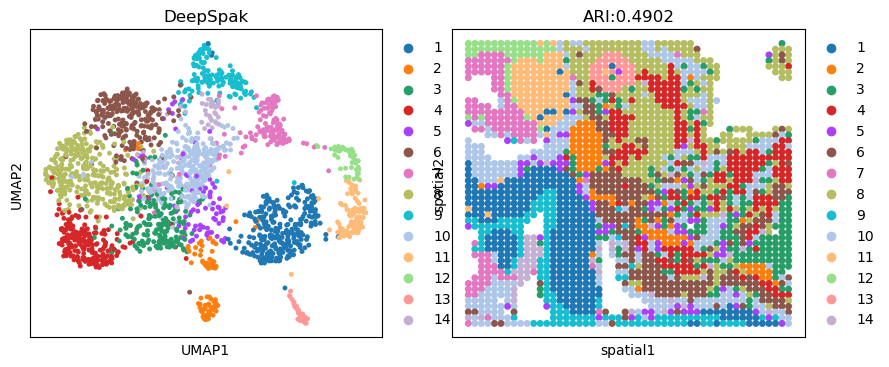

In [52]:
sc.pp.neighbors(adata, use_rep='DeepSpak')
sc.tl.umap(adata)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sc.pl.umap(adata, color='DeepSpak', ax=ax[0], s=50, show=False)
sc.pl.embedding(adata, basis='spatial', color='DeepSpak', ax=ax[1], s=100, show=False,title=f'ARI:{ari:.4f}')
plt.show()